In [1]:
import numpy as np
import pandas as pd

print("Debug: Librarie imported succesfully")

filepath="Dataset/Titanic-Dataset.csv"

Debug: Librarie imported succesfully


In [2]:
from pandas._libs.tslibs import timedeltas


# Functions Defination
def pearson_correlation(x,y) :
    arr_x = np.array(x)
    arr_x
    arr_y = np.array(y)
    arr_y

    arr_size = np.maximum(np.size(arr_x),np.size(arr_y))
    print(arr_size)

    mean_x = np.mean(arr_x)
    print("Debug: Mean of x = ",mean_x)
    mean_y = np.mean(arr_y)
    print("Debug: Mean of y = ",mean_y)

    corr_numerator=0
    corr_denominator=0

    for values in range(0,arr_size):

        print("Debug: Iteration Cycle : ",values)
        corr_x=(arr_x[values] - mean_x)
        print("Debug: Corr_x: ",corr_x)
        corr_y=(arr_y[values] - mean_y)
        print("Debug: Corr_y: ",corr_y)

        corr_numerator+=(corr_x)*(corr_y)
        print("Debug: corr_numerator: ",corr_numerator)

        corr_denominator+=np.sqrt(pow((corr_x),2) * pow((corr_y),2))
        print("Debug: corr_denominator: ",corr_denominator)

    if (corr_denominator == 0):
        return 0

    correlation=corr_numerator/corr_denominator

    return correlation



# Debug Test Module
# x=[2,6,2,3,2,1,3,5,2,1,9,4,1]
# y=[6,3,2,6,3,2,2,5,4,7,4,2,1]

# pearson_correlation(x,y)


In [3]:
# Importing Dataset

dataset=pd.read_csv(filepath)

dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:

# Data Cleaning Operations - Dropping Non-Required Data

transformDataset=dataset

transformDataset.drop(columns=["PassengerId","Name","Survived","Ticket"],inplace=True)

CleanedDataset=transformDataset

In [5]:
# Data cleaning operations - Duplicate Data



transformDataset=CleanedDataset

dupCount = transformDataset.duplicated().sum()



print("Debug : No. of Duplicate Rows - ", dupCount)


# Drop Duplicate Data
transformDataset.drop_duplicates(inplace=True) 

DupRemDataset=transformDataset

DupRemDataset.head(25)

Debug : No. of Duplicate Rows -  119


,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,22.0,1,0,7.2500,NaN,S
1,1,female,38.0,1,0,71.2833,C85,C
2,3,female,26.0,0,0,7.9250,NaN,S
3,1,female,35.0,1,0,53.1000,C123,S
4,3,male,35.0,0,0,8.0500,NaN,S
5,3,male,NaN,0,0,8.4583,NaN,Q
6,1,male,54.0,0,0,51.8625,E46,S
7,3,male,2.0,3,1,21.0750,NaN,S
8,3,female,27.0,0,2,11.1333,NaN,S
9,2,female,14.0,1,0,30.0708,NaN,C


In [6]:

transformDataset=DupRemDataset

transformDataset["Age"].fillna(transformDataset.Age.median(),inplace=True)
transformDataset["Embarked"].fillna(transformDataset.Embarked.mode(),inplace=True)
transformDataset["Cabin"].fillna(transformDataset.Cabin.mode()[0],inplace=True)

transformDataset.head(125)

CleanedDataset=transformDataset

In [7]:

CleanedDataset['Sex'] = CleanedDataset['Sex'].map({'male': 0, 'female': 1})

CleanedDataset['Embarked'] = CleanedDataset['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})


CleanedDataset['Cabin'] = CleanedDataset['Cabin'].astype(str)
CleanedDataset['Cabin_Letter'] = CleanedDataset['Cabin'].str[0]
CleanedDataset['Cabin_Encoded'] = CleanedDataset['Cabin_Letter'].astype('category').cat.codes


CleanedDataset.drop(columns=['Cabin', 'Cabin_Letter'], inplace=True)


print(CleanedDataset[['Cabin_Encoded']].head())

CleanedDataset

   Cabin_Encoded
0              1
1              2
2              1
3              2
4              1


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Cabin_Encoded
0,3,0,22.0,1,0,7.2500,0.0,1
1,1,1,38.0,1,0,71.2833,1.0,2
2,3,1,26.0,0,0,7.9250,0.0,1
3,1,1,35.0,1,0,53.1000,0.0,2
4,3,0,35.0,0,0,8.0500,0.0,1
...,...,...,...,...,...,...,...,...
885,3,1,39.0,0,5,29.1250,2.0,1
887,1,1,19.0,0,0,30.0000,0.0,1
888,3,1,28.5,1,2,23.4500,0.0,1
889,1,0,26.0,0,0,30.0000,1.0,2


In [8]:
columns = CleanedDataset.columns
num_cols = len(columns)


correlation_matrix = np.zeros((num_cols, num_cols))

for i in range(num_cols):
    for j in range(num_cols):
        x = CleanedDataset[columns[i]]
        y = CleanedDataset[columns[j]]
        r = pearson_correlation(x, y)
        correlation_matrix[i][j] = r


correlation_matrix = np.round(correlation_matrix, 3)


corr_df = pd.DataFrame(correlation_matrix, index=columns, columns=columns)
print("Correlation Matrix:")
print(corr_df)

772
Debug: Mean of x =  2.2344559585492227
Debug: Mean of y =  2.2344559585492227
Debug: Iteration Cycle :  0
Debug: Corr_x:  0.7655440414507773
Debug: Corr_y:  0.7655440414507773
Debug: corr_numerator:  0.5860576794007893
Debug: corr_denominator:  0.5860576794007893
Debug: Iteration Cycle :  1
Debug: Corr_x:  -1.2344559585492227
Debug: Corr_y:  -1.2344559585492227
Debug: corr_numerator:  2.10993919299847
Debug: corr_denominator:  2.10993919299847
Debug: Iteration Cycle :  2
Debug: Corr_x:  0.7655440414507773
Debug: Corr_y:  0.7655440414507773
Debug: corr_numerator:  2.695996872399259
Debug: corr_denominator:  2.695996872399259
Debug: Iteration Cycle :  3
Debug: Corr_x:  -1.2344559585492227
Debug: Corr_y:  -1.2344559585492227
Debug: corr_numerator:  4.21987838599694
Debug: corr_denominator:  4.21987838599694
Debug: Iteration Cycle :  4
Debug: Corr_x:  0.7655440414507773
Debug: Corr_y:  0.7655440414507773
Debug: corr_numerator:  4.805936065397729
Debug: corr_denominator:  4.805936065397

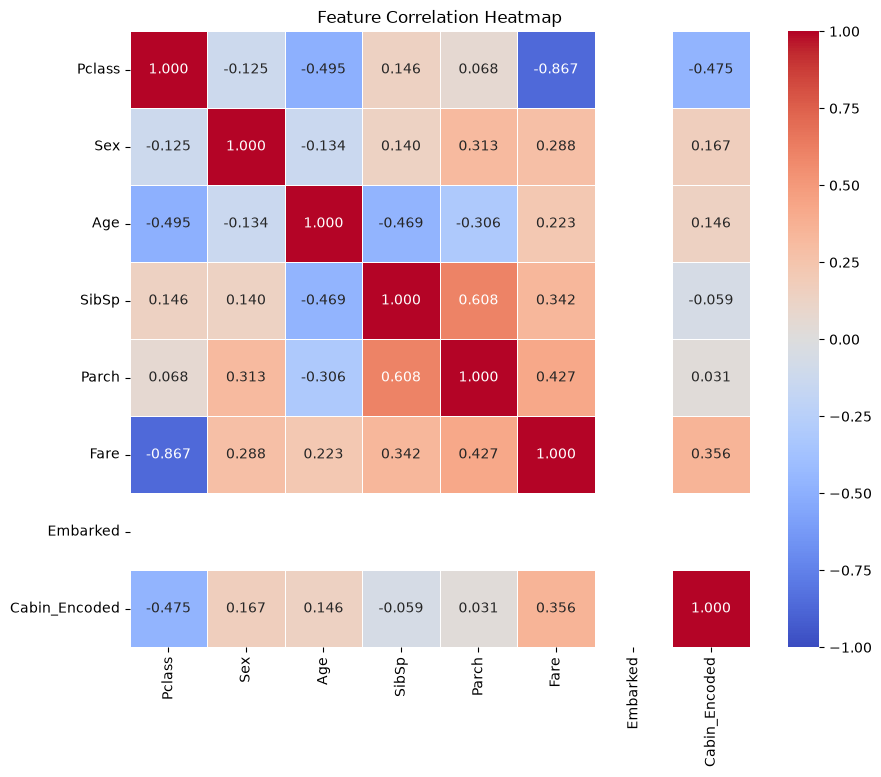

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 8))


sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".3f", linewidths=0.5, vmin=-1, vmax=1)


plt.title("Feature Correlation Heatmap")
plt.show()